In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.metrics import r2_score , mean_squared_error , accuracy_score , confusion_matrix , classification_report
from math import sqrt

# Load dataset
data = pd.read_csv('../dataSet/Housing.csv')
df = pd.DataFrame(data)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

x = df[['area','bathrooms','bedrooms','stories','parking']]
y = df['price']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale target variable (price) using MinMaxScaler
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()

lr = LinearRegression()
lr.fit(x_train, y_train_scaled)
y_pred_scaled = lr.predict(x_test)
# Inverse transform predictions back to original price scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

print('Multiple Linear Regression Model Performance:')
print('intercept (scaled):', lr.intercept_)
print('coefficients (scaled):', lr.coef_)
# Convert model parameters to original price units (MinMaxScaler)
# For MinMaxScaler: X_scaled = X * scale_ + min_  => X = (X_scaled - min_) / scale_
slope_original = lr.coef_ / scaler_y.scale_[0]
intercept_original = (lr.intercept_ - scaler_y.min_[0]) / scaler_y.scale_[0]
print('intercept (original units):', intercept_original)
print('coefficients (original units):', slope_original)

# Model evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f'\nR² Score: {r2:.4f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

Multiple Linear Regression Model Performance:
intercept (scaled): -0.16171431649439671
coefficients (scaled): [2.94159006e-05 1.12926830e-01 1.44044524e-02 4.71524536e-02
 3.21581743e-02]
intercept (original units): 51999.676808834396
coefficients (original units): [3.08866956e+02 1.18573171e+06 1.51246751e+05 4.95100763e+05
 3.37660830e+05]

R² Score: 0.5464
MSE: 2292721545725.36
RMSE: 1514173.55
MAE: 1127483.35


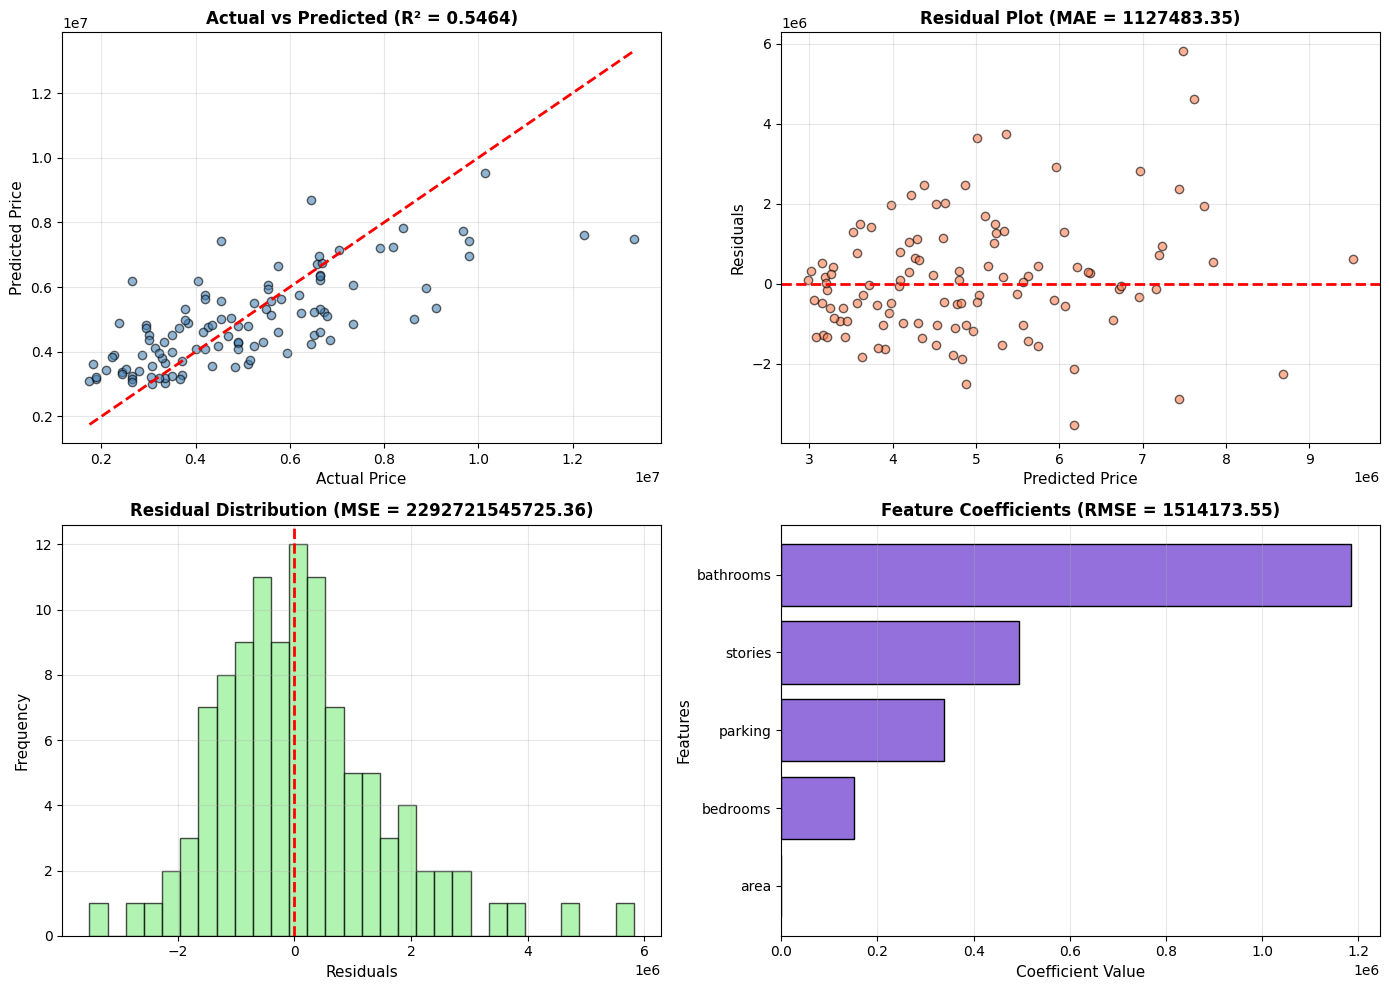

In [59]:
# Visualize all 4 metrics in one graph
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k', color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price', fontsize=11)
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Plot
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.6, edgecolors='k', color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)
axes[0, 1].set_title(f'Residual Plot (MAE = {mae:.2f})', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='k', alpha=0.7, color='lightgreen')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title(f'Residual Distribution (MSE = {mse:.2f})', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature Coefficients
coefficients_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': slope_original
})
coefficients_df = coefficients_df.sort_values('Coefficient', ascending=True)
axes[1, 1].barh(coefficients_df['Feature'], coefficients_df['Coefficient'], 
                color='mediumpurple', edgecolor='k')
axes[1, 1].set_xlabel('Coefficient Value', fontsize=11)
axes[1, 1].set_ylabel('Features', fontsize=11)
axes[1, 1].set_title(f'Feature Coefficients (RMSE = {rmse:.2f})', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

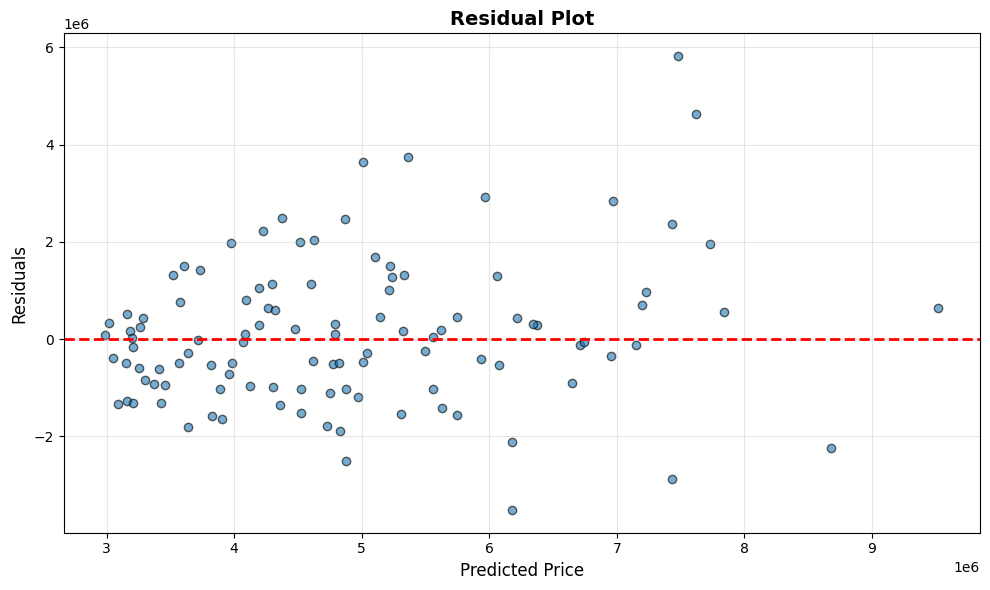

In [60]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Logistic Regression (Price -> Low to High)
df['price_cat']=np.where(df['price'] > df['price'].median(), 1, 0)

x = df[['area','bathrooms','bedrooms','stories','parking']]
y = df['price_cat']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

logr = LogisticRegression(max_iter=200)
logr.fit(x_train, y_train)
y_pred = logr.predict(x_test)

acc = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Model Accuracy: {acc:.4f}')
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)


Logistic Regression Model Accuracy: 0.7615
Confusion Matrix:
 [[40 11]
 [15 43]]


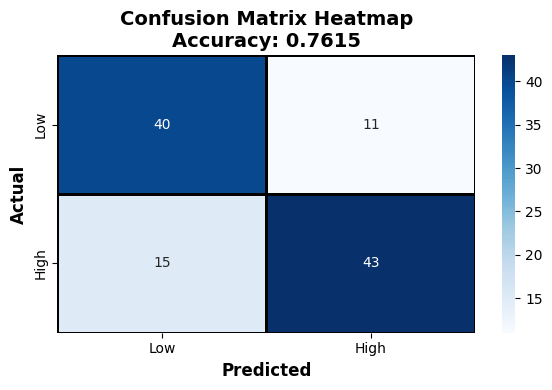

In [62]:
# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'],
            linewidths=2, linecolor='black')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix Heatmap\nAccuracy: {acc:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [63]:
# Calculate Sensitivity, Specificity, PPV, and NPV from confusion matrix
# Confusion Matrix structure:
# [[TN, FP],
#  [FN, TP]]

TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives
TP = cm[1, 1]  # True Positives

# Sensitivity (Recall / True Positive Rate)
# Measures the proportion of actual positives correctly identified
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0

# Specificity (True Negative Rate)
# Measures the proportion of actual negatives correctly identified
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

# Positive Predictive Value (Precision)
# Measures the proportion of positive predictions that are correct
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0

# Negative Predictive Value
# Measures the proportion of negative predictions that are correct
npv = TN / (TN + FN) if (TN + FN) > 0 else 0

print("=" * 50)
print("CLASSIFICATION METRICS")
print("=" * 50)
print(f"\nConfusion Matrix Components:")
print(f"True Positives (TP):  {TP}")
print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"\n{'-' * 50}")
print(f"Sensitivity (Recall/TPR):        {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity (TNR):               {specificity:.4f} ({specificity*100:.2f}%)")
print(f"Positive Predictive Value (PPV): {ppv:.4f} ({ppv*100:.2f}%)")
print(f"Negative Predictive Value (NPV): {npv:.4f} ({npv*100:.2f}%)")
print(f"Accuracy:                        {acc:.4f} ({acc*100:.2f}%)")
print("=" * 50)

CLASSIFICATION METRICS

Confusion Matrix Components:
True Positives (TP):  43
True Negatives (TN):  40
False Positives (FP): 11
False Negatives (FN): 15

--------------------------------------------------
Sensitivity (Recall/TPR):        0.7414 (74.14%)
Specificity (TNR):               0.7843 (78.43%)
Positive Predictive Value (PPV): 0.7963 (79.63%)
Negative Predictive Value (NPV): 0.7273 (72.73%)
Accuracy:                        0.7615 (76.15%)


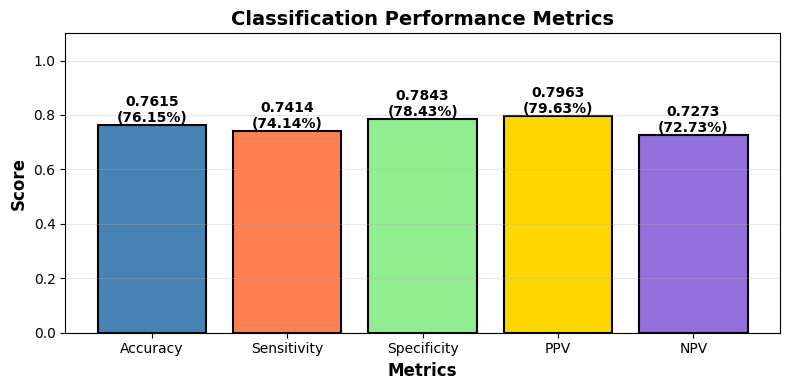

In [64]:
# Visualize all metrics in a bar chart
metrics_names = ['Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV']
metrics_values = [acc, sensitivity, specificity, ppv, npv]

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics_names, metrics_values, color=['steelblue', 'coral', 'lightgreen', 'gold', 'mediumpurple'], 
               edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}\n({value*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.title('Classification Performance Metrics', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [65]:
# Linear vs Exponential Regression
from scipy.optimize import curve_fit

# Use single feature for comparison
x = df['area'].values
y = df['price'].values

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define logarithmic function
def log_fn(x, a, b):
    x = np.where(x <= 0, 1e-6, x)  # Avoid log(0)
    return a * np.log(x) + b

# Define exponential function
def exp_fn(x, a, b):
    return a * np.exp(b * x)

In [66]:
# Fit Exponential Model
params_exp, _ = curve_fit(exp_fn, x_train, y_train, maxfev=10000, p0=[1, 0.0001])
a_exp, b_exp = params_exp

y_pred_exp = exp_fn(x_test, a_exp, b_exp)
mse_exp = mean_squared_error(y_test, y_pred_exp)
rmse_exp = sqrt(mse_exp)
r2_exp = r2_score(y_test, y_pred_exp)

print(f'Exponential Model Performance:')
print(f'Parameters: a={a_exp:.4f}, b={b_exp:.6f}')
print(f'R² Score: {r2_exp:.4f}')
print(f'MSE: {mse_exp:.2f}')
print(f'RMSE: {rmse_exp:.2f}')

Exponential Model Performance:
Parameters: a=3258028.5927, b=0.000069
R² Score: 0.2355
MSE: 3864386599534.28
RMSE: 1965804.31


In [67]:
# Logarithmic Model
params_log, _ = curve_fit(log_fn, x_train, y_train, maxfev=10000)
a_log, b_log = params_log

y_pred_log = log_fn(x_test, a_log, b_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = sqrt(mse_log)
r2_log = r2_score(y_test, y_pred_log)

print(f'Logarithmic Model Performance:')
print(f'Parameters: a={a_log:.4f}, b={b_log:.4f}')
print(f'R² Score: {r2_log:.4f}')
print(f'MSE: {mse_log:.2f}')
print(f'RMSE: {rmse_log:.2f}')

Logarithmic Model Performance:
Parameters: a=2485283.0814, b=-16335243.3075
R² Score: 0.2938
MSE: 3569446884492.87
RMSE: 1889297.99


In [68]:
# Fit Linear Model for comparison
lr_simple = LinearRegression()
lr_simple.fit(x_train.reshape(-1, 1), y_train)
y_pred_linear = lr_simple.predict(x_test.reshape(-1, 1))

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f'Linear Model Performance:')
print(f'Parameters: slope={lr_simple.coef_[0]:.4f}, intercept={lr_simple.intercept_:.4f}')
print(f'R² Score: {r2_linear:.4f}')
print(f'MSE: {mse_linear:.2f}')
print(f'RMSE: {rmse_linear:.2f}')

Linear Model Performance:
Parameters: slope=425.7298, intercept=2512254.2640
R² Score: 0.2729
MSE: 3675286604768.19
RMSE: 1917103.70


In [69]:
# Compare Models: Linear vs Logarithmic vs Exponential
print("\n" + "=" * 60)
print("MODEL COMPARISON: Linear vs Logarithmic vs Exponential")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': ['Linear', 'Logarithmic', 'Exponential'],
    'R² Score': [r2_linear, r2_log, r2_exp],
    'MSE': [mse_linear, mse_log, mse_exp],
    'RMSE': [rmse_linear, rmse_log, rmse_exp]
})

print(comparison_df.to_string(index=False))
print("=" * 60)

# Determine best model
best_model_idx = comparison_df['R² Score'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\nBest Model: {best_model} (Highest R² Score: {comparison_df.loc[best_model_idx, 'R² Score']:.4f})")


MODEL COMPARISON: Linear vs Logarithmic vs Exponential
      Model  R² Score          MSE         RMSE
     Linear  0.272879 3.675287e+12 1.917104e+06
Logarithmic  0.293818 3.569447e+12 1.889298e+06
Exponential  0.235467 3.864387e+12 1.965804e+06

Best Model: Logarithmic (Highest R² Score: 0.2938)


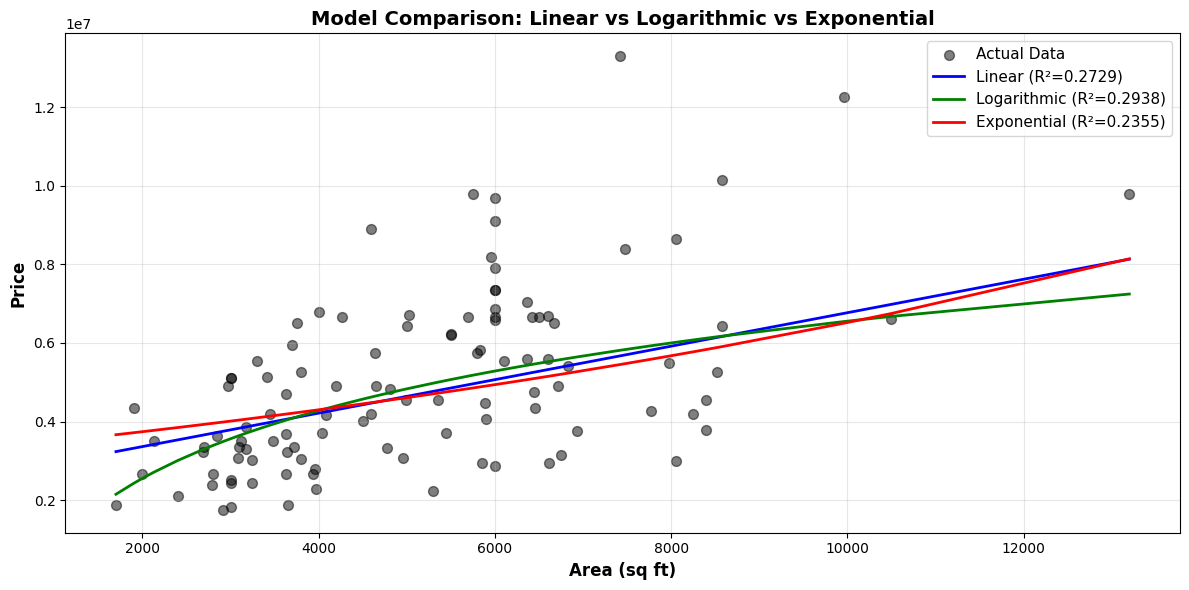

In [70]:
# Visualize all three models
plt.figure(figsize=(12, 6))

# Sort data for better line plotting
sort_idx = np.argsort(x_test)
x_test_sorted = x_test[sort_idx]
y_test_sorted = y_test[sort_idx]

# Plot actual data
plt.scatter(x_test, y_test, alpha=0.5, color='black', label='Actual Data', s=50)

# Plot predictions
plt.plot(x_test_sorted, lr_simple.predict(x_test_sorted.reshape(-1, 1)), 
         'b-', linewidth=2, label=f'Linear (R²={r2_linear:.4f})')
plt.plot(x_test_sorted, log_fn(x_test_sorted, a_log, b_log), 
         'g-', linewidth=2, label=f'Logarithmic (R²={r2_log:.4f})')
plt.plot(x_test_sorted, exp_fn(x_test_sorted, a_exp, b_exp), 
         'r-', linewidth=2, label=f'Exponential (R²={r2_exp:.4f})')

plt.xlabel('Area (sq ft)', fontsize=12, fontweight='bold')
plt.ylabel('Price', fontsize=12, fontweight='bold')
plt.title('Model Comparison: Linear vs Logarithmic vs Exponential', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()